### 0. Import packages

In [5]:
import logomaker
import glob as glob
import sys, os

os.path.dirname(sys.executable)

import pandas as pd
import seaborn as sns 
import numpy as np 
import matplotlib.pyplot as plt

import sys, os, json, textwrap, itertools, requests
from pathlib import Path

from Bio.PDB import PDBParser, NeighborSearch, is_aa
from Bio.Data.IUPACData import protein_letters_3to1

import re
from typing import Optional          

from Bio.PDB import PDBParser, NeighborSearch
from scipy.spatial.distance import cdist

from collections import Counter
from itertools import combinations
from scipy.spatial.distance import pdist, squareform
from scipy.stats import entropy
from scipy.spatial.distance import jensenshannon


### 1. Exploration of structure-dervied peptides

In [4]:
def grab_hla(title: str) -> Optional[str]:   # <- use Optional[str] instead of str | None
    """
    Return the first HLA allele in *title* or None.
    Handles:  HLA-A*02:01,  HLA-A02:01,  HLA-A*0201,  HLA-A0201
    """
    patterns = [
        r'(HLA-[A-Z]\*\d{2}:\d{2})',   # HLA-A*02:01
        r'(HLA-[A-Z]\d{2}:\d{2})',     # HLA-A02:01
        r'([A-Z]\*\d{4})',         # HLA-A*0201
        r'(-[A-Z]\*\d{2}:\d{2})'  ,
        r'([A-Z]\d{2}\d{2})'  ,
        r'([A-Z]\*\d{2}:\d{2})' ,
        r'(-[A-Z]\d{1}:\d{2})'  ,
        r'(-[A-Z]\d{1})'   ,
        r'(-[A-Z]\d{2})'            # HLA-A0201
    ]
    for p in patterns:
        m = re.search(p, title, flags=re.IGNORECASE)
        if m:
            return m.group(1).upper()
    return None

# results_meta = pd.merge(results_pdbs, df_meta, left_on='PDB', right_on='pdb_id', how='left')

results_meta = pd.read_csv('../data/rdfiffusion_output_peptides.csv.gz',compression='gzip')

results_meta['hla_allele'] = results_meta['title'].apply(grab_hla)
results_meta['hla_allele'] = results_meta['hla_allele'].str.replace('HLA','').str.replace('-','').str.replace(':','').str.replace('*','')
results_meta['epitope'] = results_meta['seq'].apply(lambda x: x.split("/")[1])
results_meta['length'] = results_meta['epitope'].apply(lambda x: len(x))
results_meta = results_meta.drop_duplicates(['pdb_id', 'epitope'])

In [6]:
# keep only one copy of each (pdb_id, epitope) pair
peptides_by_pdb = (
    results_meta[(results_meta['plddt'] > 0.8) ] # & (results_meta['length'] == 11)]
    .loc[:, ['pdb_id', 'epitope']]
    .drop_duplicates()
    .groupby('pdb_id')['epitope']
    .apply(list)
)
pdb_ids = peptides_by_pdb.index.tolist()

AA = "ACDEFGHIKLMNPQRSTVWY"

def build_pwm(seqs, max_len=10):
    """
    Return a (L × 20) frequency matrix, padding shorter peptides
    with '-' and ignoring them in the counts.
    """
    if not seqs:
        return np.zeros((max_len, 20))
    L = max_len
    mat = np.zeros((L, 20))
    for s in seqs:
        for i, aa in enumerate(s):
            if i >= L: break
            j = AA.index(aa)
            mat[i, j] += 1
    # convert to prob’s (add pseudocount to avoid 0)
    mat += 1e-6
    mat /= mat.sum(axis=1, keepdims=True)
    return mat

# build a PWM per PDB
pwms = {pdb: build_pwm(peps) for pdb, peps in peptides_by_pdb.items()}

def pwm_distance(M1, M2, metric="js"):
    if metric == "js":       # Jensen–Shannon divergence averaged over positions
        return np.mean([jensenshannon(M1[i], M2[i]) for i in range(M1.shape[0])])
    elif metric == "l1":     # simple L1 difference
        return np.sum(np.abs(M1 - M2))
    elif metric == "euclid": # Euclidean distance averaged over positions
        return np.mean([np.linalg.norm(M1[i] - M2[i]) for i in range(M1.shape[0])])
    else:
        raise ValueError("metric must be 'js', 'l1' or 'euclid'")

def pwm_distance_matrix(metric="js"):
    n = len(pdb_ids)
    D = np.zeros((n, n))
    for i, j in combinations(range(n), 2):
        d = pwm_distance(pwms[pdb_ids[i]], pwms[pdb_ids[j]], metric)
        D[i, j] = D[j, i] = d
    return pd.DataFrame(D, index=pdb_ids, columns=pdb_ids)

pwm_js   = pwm_distance_matrix(metric="js")   # divergence    (0 == identical)
pwm_l1   = pwm_distance_matrix(metric="l1")   # absolute diff (0 == identical)
pwm_euclid = pwm_distance_matrix(metric="euclid")  # Euclidean

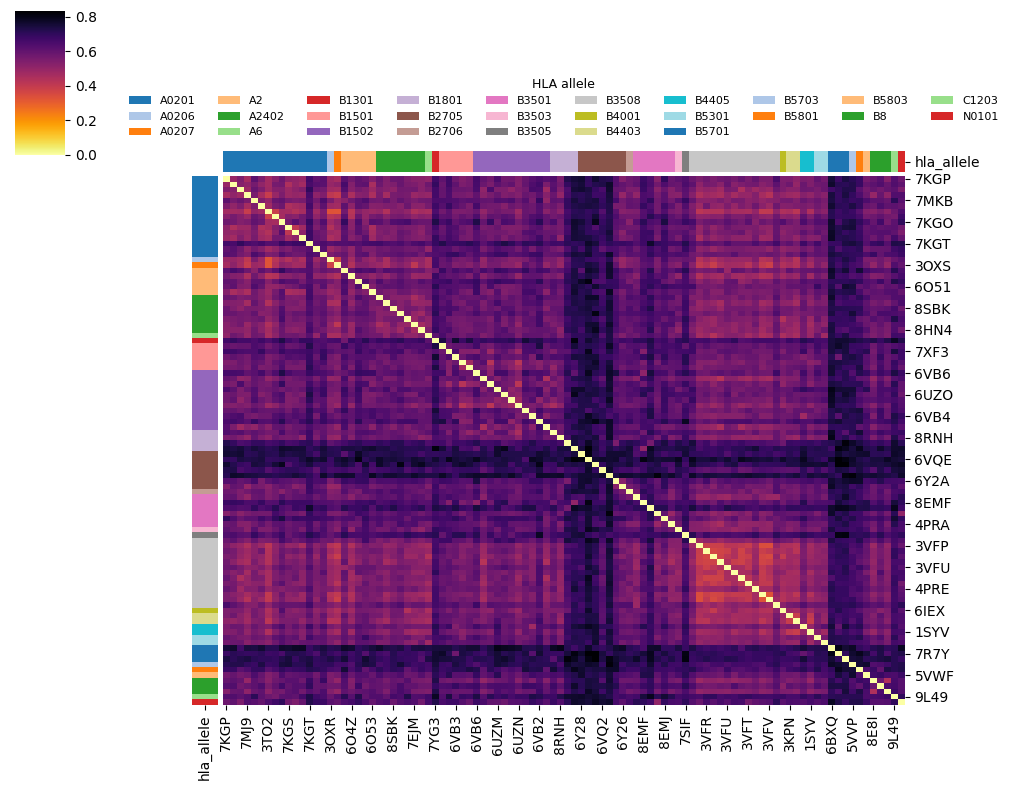

In [7]:
# -------------------------------------------------------------
# 1 .  Map every PDB to its HLA allele
# -------------------------------------------------------------
# results_meta must contain a column named 'hla_allele' (grab_hla() gave you that).
pdb2hla = (
    results_meta[['pdb_id', 'hla_allele']]
    .dropna()
    .drop_duplicates(subset='pdb_id')
    .set_index('pdb_id')['hla_allele']
)

# fallback label for structures where HLA wasn’t detected
pwm_euclid = pwm_euclid.loc[pdb2hla.index.intersection(pwm_euclid.index)]  # keep only mapped PDBs
pdb2hla = pdb2hla.reindex(pwm_euclid.index).fillna('UNK')

# -------------------------------------------------------------
# 2 .  Re-order the matrix by HLA group, then by PDB
# -------------------------------------------------------------
order = (
    pdb2hla
    .sort_values(kind='mergesort')  # stable: keeps original PDB order within HLA block
    .index
)

M = pwm_js.loc[order, order]            # reordered similarity matrix
hla_order = pdb2hla.loc[order]          # parallel HLA list

# -------------------------------------------------------------
# 3 .  Build stripe colours for the clustermap
# -------------------------------------------------------------
unique_hla = hla_order.unique()
palette    = sns.color_palette('tab20', len(unique_hla))
color_map  = dict(zip(unique_hla, palette))
row_colors = hla_order.map(color_map)

# -------------------------------------------------------------
# 4 .  Draw the heatmap
# -------------------------------------------------------------
g = sns.clustermap(
        M,
        cmap='inferno_r',
        row_cluster=False,
        col_cluster=False,
        row_colors=row_colors,
        col_colors=row_colors,
        linewidths=0.0,  # no tiny grid lines
        figsize=(10, 8)
    )

# -------------------------------------------------------------
# 5 .  Add bold white lines between HLA blocks
# -------------------------------------------------------------
# Find cumulative sizes of each HLA group
group_sizes = hla_order.value_counts(sort=False).loc[unique_hla].values
cuts = np.cumsum(group_sizes)

for cut in cuts[:-1]:                       # skip last cumulative (matrix edge)
    g.ax_heatmap.axhline(cut,  color='white', lw=0)
    g.ax_heatmap.axvline(cut,  color='white', lw=0)

# -------------------------------------------------------------
# 6 .  Pretty titles & legend
# -------------------------------------------------------------
# g.ax_heatmap.set_title('PWM-L1 dissimilarity of peptide sets (grouped by HLA)', pad=16)

# Build a tiny legend for the stripe colours
for hla, col in color_map.items():
    g.ax_col_dendrogram.bar(0, 0, color=col, label=hla, linewidth=0)
g.ax_col_dendrogram.legend(
    loc='lower center',
    ncol=10,
    title='HLA allele',
    frameon=False,
    fontsize=8,
    title_fontsize=9
)

plt.show()

In [8]:
from scipy.spatial.distance import jensenshannon
from Bio import pairwise2                         # Biopython local-align for unequal lengths

# -----------------------------------------------------------------------------------
# Part A – counts per allele / pLDDT tier
# -----------------------------------------------------------------------------------
# 1. mark confidence tier (your tmp DataFrame)
tmp = (
    results_meta
      .drop_duplicates(subset=['epitope', 'PDB'])
      .assign(conf=lambda d: np.where(d['plddt'] >= 0.8,
                                      'HIGH_PLDDT', 'LOW_PLDDT'))
)

# 2. peptide counts per allele + tier
epi_counts = (tmp.groupby(['hla_allele', 'conf'])
                   .size().reset_index(name='n_epitopes'))

# 3. number of distinct PDBs per allele
struct_counts = (tmp.groupby('hla_allele')['PDB']
                     .nunique()
                     .reset_index()
                     .rename(columns={'PDB': 'n_structures'}))

# 4. merge & pivot into final summary table
allele_summary = (struct_counts
                  .merge(epi_counts, on='hla_allele', how='left')
                  .pivot_table(index=['hla_allele', 'n_structures'],
                               columns='conf',
                               values='n_epitopes',
                               fill_value=0)
                  .reset_index()
                  .sort_values('n_structures', ascending=False))

# 5. save & show
# out_csv = '/global/scratch/users/sergiomar10/ESMCBA/analysis/allele_summary.csv'
# allele_summary.to_csv(out_csv, index=False)
# display(allele_summary.head())


/clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian/lib/python3.10/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [9]:
allele_summary['sum'] = allele_summary['HIGH_PLDDT'].astype(int) + allele_summary['LOW_PLDDT'].astype(int)

In [31]:
"""
pwm_distance.py
Compare peptide-binding motifs (PWMs) between *predicted* designs and *training* data,
and estimate the intrinsic variability of the training data via bootstrap splits.
"""

episcan_epitopes = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/rdfiffusion/41587_2022_1566_MOESM5_ESM 2.csv', header = 1)
episcan_epitopes

# ──────────────────────────────────────────────────────────────────────────────
# 0  Imports & global settings
# ──────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from collections import defaultdict
from scipy.spatial.distance import euclidean
from scipy.stats import entropy                            # for Jensen–Shannon

AA = list("ACDEFGHIKLMNPQRSTVWY")   # 20-aa alphabet
PSEUDOCOUNT = 1                     # avoids log(0) and /0 problems
PEPTIDE_LEN = 9                     # change to 8, 10, 11… if needed
RNG_SEED     = 42                   # global reproducibility


# ──────────────────────────────────────────────────────────────────────────────
# 1  Core helper functions
# ──────────────────────────────────────────────────────────────────────────────
def build_pwm(df: pd.DataFrame,
              seq_col: str,
              allele_col: str,
              length: int = PEPTIDE_LEN,
              pseudocount: int = PSEUDOCOUNT):
    """
    Return {allele: (L, 20) numpy array} where rows = positions,
    columns = AA probabilities.
    Only sequences of exact 'length' are used.
    """
    pwm = {}
    for hla, grp in df[df[seq_col].str.len() == length].groupby(allele_col):
        counts = np.zeros((length, 20))
        for seq in grp[seq_col]:
            for i, aa in enumerate(seq):
                if aa in AA:
                    counts[i, AA.index(aa)] += 1
        counts += pseudocount
        pwm[hla] = counts / counts.sum(axis=1, keepdims=True)
    return pwm


def jensen_shannon(p: np.ndarray, q: np.ndarray, base: int = 2) -> float:
    """
    Symmetric JS divergence (0 = identical, ≤ log2 bits).
    Expects *probability* vectors of equal length.
    """
    m = 0.5 * (p + q)
    return 0.5 * entropy(p, m, base=base) + 0.5 * entropy(q, m, base=base)


def split_per_allele(df: pd.DataFrame,
                     allele_col: str,
                     frac: float = 0.5,
                     seed: int = RNG_SEED):
    """
    Return two dataframes (A, B) where each HLA allele’s rows are randomly
    split in the same proportion 'frac'.
    """
    rng = np.random.default_rng(seed)
    partA, partB = [], []

    for hla, grp in df.groupby(allele_col):
        idx = grp.index.to_numpy()
        rng.shuffle(idx)
        cut = int(len(idx) * frac)
        partA.append(grp.loc[idx[:cut]])
        partB.append(grp.loc[idx[cut:]])

    return pd.concat(partA), pd.concat(partB)


def compute_distances(pwm1: dict, pwm2: dict):
    """
    Compare PWMs allele-wise; return tidy DataFrame with JS and L2.
    """
    rows = []
    for hla in set(pwm1) & set(pwm2):
        p = pwm1[hla].flatten()
        q = pwm2[hla].flatten()
        rows.append({
            "HLA": hla,
            "JS_bits": jensen_shannon(p, q),
            "L2": euclidean(p, q)
        })
    return pd.DataFrame(rows)


def bootstrap_baseline(df: pd.DataFrame,
                       seq_col: str,
                       allele_col: str,
                       n_iter: int = 100,
                       length: int = PEPTIDE_LEN):
    """
    Re-sample training data 'n_iter' times, splitting each time;
    returns DataFrame with JS divergence per iteration & allele.
    """
    out = defaultdict(list)
    for i in range(n_iter):
        A, B = split_per_allele(df, allele_col, seed=i)
        pwm_A = build_pwm(A, seq_col, allele_col, length)
        pwm_B = build_pwm(B, seq_col, allele_col, length)
        for hla in set(pwm_A) & set(pwm_B):
            out["iter"].append(i)
            out["HLA"].append(hla)
            out["JS_bits"].append(jensen_shannon(
                pwm_A[hla].flatten(),
                pwm_B[hla].flatten()))
    return pd.DataFrame(out)


/tmp/ipykernel_743359/643196982.py:7: DtypeWarning: Columns (1,2,3,4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  episcan_epitopes = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/rdfiffusion/41587_2022_1566_MOESM5_ESM 2.csv', header = 1)


In [65]:
# results_meta = pd.merge(results_pdbs, df_meta, left_on='PDB', right_on='pdb_id', how='left')

results_meta = pd.read_csv('../data/rdfiffusion_output_peptides.csv.gz',compression='gzip')

results_meta['hla_allele'] = results_meta['title'].apply(grab_hla)
results_meta['hla_allele'] = results_meta['hla_allele'].str.replace('HLA','').str.replace('-','').str.replace(':','').str.replace('*','')
results_meta['epitope'] = results_meta['seq'].apply(lambda x: x.split("/")[1])
results_meta['length'] = results_meta['epitope'].apply(lambda x: len(x))
results_meta = results_meta.drop_duplicates(['pdb_id', 'epitope'])

In [66]:
merged_dt = results_meta # results_meta[(results_meta['hla_allele'] == 'A0201')]

In [67]:
num_sequences_test = 500

training_data = pd.DataFrame()

for formatted_HLA in ['A0201', 'B1501', 'B5701','B1801','A0206']:
    
    train_fasta = f"/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLA{formatted_HLA}_final.csv"

    train_fasta = pd.read_csv(train_fasta, header=None)
    train_fasta.columns = ['sequence', 'ref_ID', 'submissionID', 'Epitope_ID', 'protein_origin', 
                        'ID_SOURCE', 'SOURCE_ORGANISM', 'IC50_nM', 'DESCRIPTION_BINDING', 'Year_submission']
    train_fasta['HLA'] = formatted_HLA
   #  train_fasta = train_fasta[['sequence','HLA']].head(num_sequences_test)
    training_data = pd.concat([training_data, train_fasta])


In [68]:
episcan_epitopes = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/rdfiffusion/41587_2022_1566_MOESM5_ESM 2.csv', header = 1)

# Keep only the columns of interest
df = episcan_epitopes[['A2 binders', 'B57 abacavir binders']]

# Map column names → proper allele names
allele_map = {
    'A2 binders':            'HLA-A*02:01',
    'B57 abacavir binders':  'HLA-B*57:01'
}

# ── Option 1: melt ───────────────────────────────────────────
long_df = (
    df.melt(value_vars=df.columns,          # the two binder columns
            var_name='HLA',                 # new column holding the column names
            value_name='sequence')          # new column holding the sequences
      .dropna(subset=['sequence'])          # remove rows where the sequence was NaN
      .replace({'HLA': allele_map})         # pretty allele names
      .reset_index(drop=True)
)

# ── Option 2: concat (explicit) ──────────────────────────────
alt_df = (
    pd.concat([
        df['A2 binders']
          .dropna()
          .rename('sequence')
          .to_frame()
          .assign(HLA='HLA-A*02:01'),

        df['B57 abacavir binders']
          .dropna()
          .rename('sequence')
          .to_frame()
          .assign(HLA='HLA-B*57:01')
    ])
    .reset_index(drop=True)
)

long_df['HLA'] = long_df['HLA'].str.replace('*','').str.replace('HLA-','').str.replace(':','')
# long_df['HLA']

/tmp/ipykernel_743359/3583045381.py:1: DtypeWarning: Columns (1,2,3,4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  episcan_epitopes = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/rdfiffusion/41587_2022_1566_MOESM5_ESM 2.csv', header = 1)


In [69]:
# ──────────────────────────────────────────────────────────────
# 2  BUILD PWMs
# ──────────────────────────────────────────────────────────────
pwm_pred     = build_pwm(merged_dt[merged_dt['plddt'] > 0.6],
                         seq_col="epitope",  allele_col="hla_allele")
pwm_train    = build_pwm(training_data,      seq_col="sequence", allele_col="HLA")
pwm_episcan  = build_pwm(long_df,   seq_col="sequence", allele_col="HLA")

# ──────────────────────────────────────────────────────────────
# 3  PAIRWISE DISTANCES
# ──────────────────────────────────────────────────────────────
# 3-A  Predicted vs Training
dist_pred_vs_train = (compute_distances(pwm_pred, pwm_train)
                      .rename(columns={"JS_bits": "JS_pred_vs_train",
                                       "L2":      "L2_pred_vs_train"}))

# 3-B  EpiScan vs Training
dist_epi_vs_train  = (compute_distances(pwm_episcan, pwm_train)
                      .rename(columns={"JS_bits": "JS_epi_vs_train",
                                       "L2":      "L2_epi_vs_train"}))

# 3-C  EpiScan vs Predicted
dist_epi_vs_pred   = (compute_distances(pwm_episcan, pwm_pred)
                      .rename(columns={"JS_bits": "JS_epi_vs_pred",
                                       "L2":      "L2_epi_vs_pred"}))

# ──────────────────────────────────────────────────────────────
# 4  TRAINING-SET NOISE FLOORS
# ──────────────────────────────────────────────────────────────
# 4-A  One 50/50 split
A, B = split_per_allele(training_data, allele_col="HLA")
baseline_split = (compute_distances(build_pwm(A, "sequence", "HLA"),
                                    build_pwm(B, "sequence", "HLA"))
                  .rename(columns={"JS_bits": "JS_split",
                                   "L2":      "L2_split"}))

# 4-B  Bootstrap median of 100 splits
boot   = bootstrap_baseline(training_data, "sequence", "HLA", n_iter=100)
median_boot = (boot.groupby("HLA")["JS_bits"].median()
               .reset_index()
               .rename(columns={"JS_bits": "JS_boot"}))

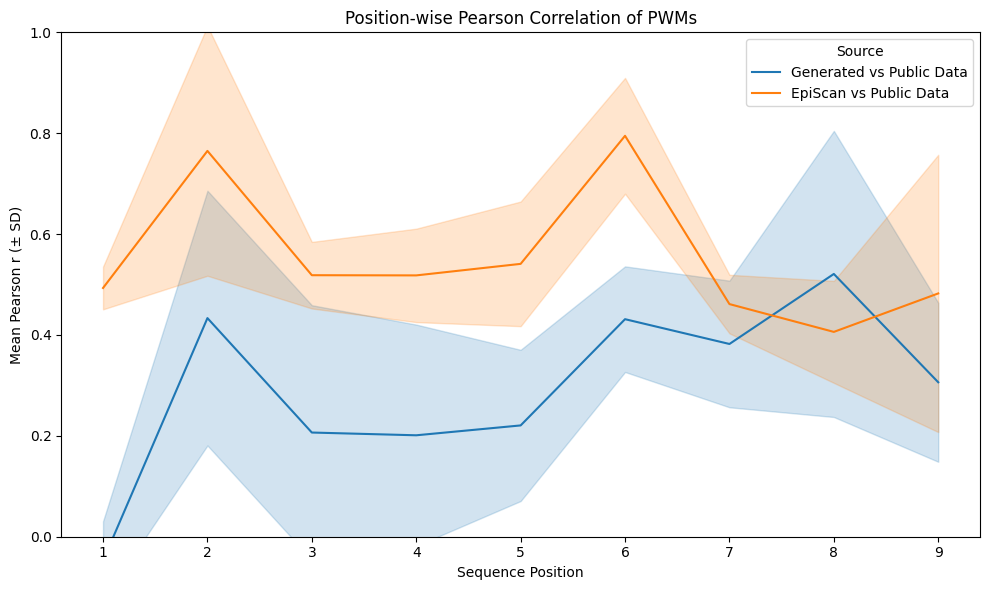

In [70]:
from scipy.stats import pearsonr

def pwm_positionwise_pearson(pwm1, pwm2):
    """
    Compute position-wise Pearson correlation between two PWMs.
    Returns: dict of HLA → list of r-values (length = sequence length)
    """
    results = {}
    for hla in pwm1:
        if hla not in pwm2:
            continue
        pwm1_mat = pwm1[hla]
        pwm2_mat = pwm2[hla]

        if isinstance(pwm1_mat, pd.DataFrame):
            pwm1_mat = pwm1_mat.values
        if isinstance(pwm2_mat, pd.DataFrame):
            pwm2_mat = pwm2_mat.values

        r_values = []
        for i in range(pwm1_mat.shape[0]):
            r, _ = pearsonr(pwm1_mat[i], pwm2_mat[i])
            r_values.append(r)
        results[hla] = r_values
    return results

pearson_pred_train = pwm_positionwise_pearson(pwm_pred, pwm_train)
pearson_epi_train  = pwm_positionwise_pearson(pwm_episcan, pwm_train)


def pearson_dict_to_long_df(pearson_dict, source_label):
    """
    Convert HLA → list of Pearson r-values into a long DataFrame
    """
    data = []
    for hla, r_values in pearson_dict.items():
        for pos, r in enumerate(r_values):
            data.append({'HLA': hla, 'Position': pos + 1, 'PearsonR': r, 'Source': source_label})
    return pd.DataFrame(data)

df_pred = pearson_dict_to_long_df(pearson_pred_train, source_label='Generated vs Public Data')
df_epi  = pearson_dict_to_long_df(pearson_epi_train,  source_label='EpiScan vs Public Data')

df_pearson = pd.concat([df_pred, df_epi], ignore_index=True)

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_pearson, x='Position', y='PearsonR', hue='Source', estimator='mean', errorbar='sd')

plt.title("Position-wise Pearson Correlation of PWMs")
plt.xlabel("Sequence Position")
plt.ylabel("Mean Pearson r (± SD)")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

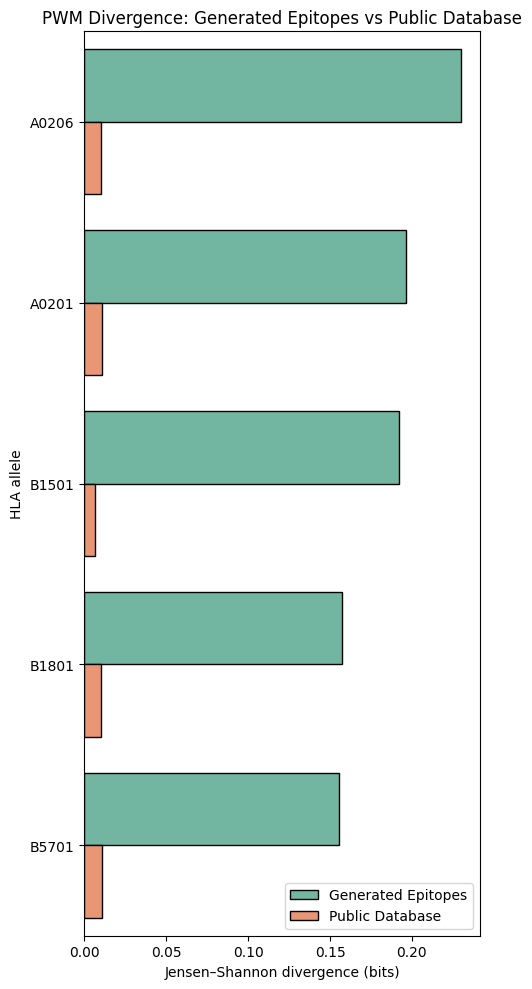

In [71]:

# ──────────────────────────────────────────────────────────────
# 1. Merge JS scores from predictions and baseline
# ──────────────────────────────────────────────────────────────
js_table = (
    dist_pred_vs_train[["HLA", "JS_pred_vs_train"]]
    .merge(baseline_split[["HLA", "JS_split"]], on="HLA")
)

# ──────────────────────────────────────────────────────────────
# 2. Convert to long format and relabel
# ──────────────────────────────────────────────────────────────
df_plot = (
    js_table.melt(id_vars="HLA", var_name="Source", value_name="JS")
    .replace({"Source": {
        "JS_pred_vs_train": "Generated Epitopes",
        "JS_split": "Public Database"
    }})
)

# Optional: order alleles by JS_pred_vs_train
allele_order = js_table.sort_values("JS_pred_vs_train", ascending=False)["HLA"]
df_plot["HLA"] = pd.Categorical(df_plot["HLA"], categories=allele_order, ordered=True)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 10))  # Taller figure for vertical HLA labels

sns.barplot(
    data=df_plot,
    y="HLA",          # HLA on the y-axis now
    x="JS",           # JS on the x-axis
    hue="Source",
    palette="Set2",
    edgecolor="black"
)

plt.xlabel("Jensen–Shannon divergence (bits)")
plt.ylabel("HLA allele")
plt.title("PWM Divergence: Generated Epitopes vs Public Database")
plt.legend(title="")
plt.tight_layout()
plt.show()

